In [37]:
import sys
sys.path.insert(0, "..")

import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [38]:
from src.evaluation.metrics import build_predictions_report

In [55]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [56]:
!ls ../artifacts/models/

level_01_daily_total_sales_artifact.pkl
level_09_daily_store_dept_sales_artifact.pkl


In [57]:
ARTIFACT = "level_09_daily_store_dept_sales_artifact"

In [58]:
import joblib

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
X_test, y_test = artifact["X_test"], artifact["y_test"]

FEATURES = artifact["features"]

feature_importance = artifact["feature_importance"]

results_df = artifact["results_df"]

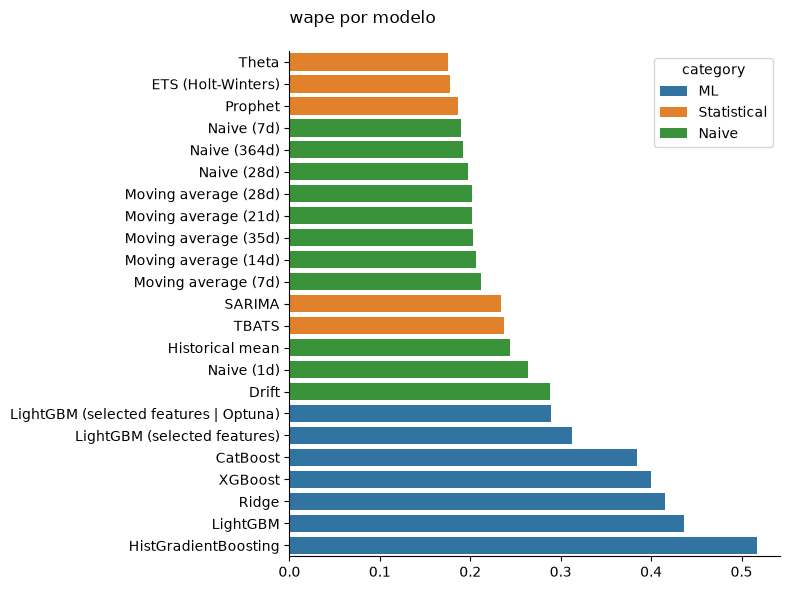

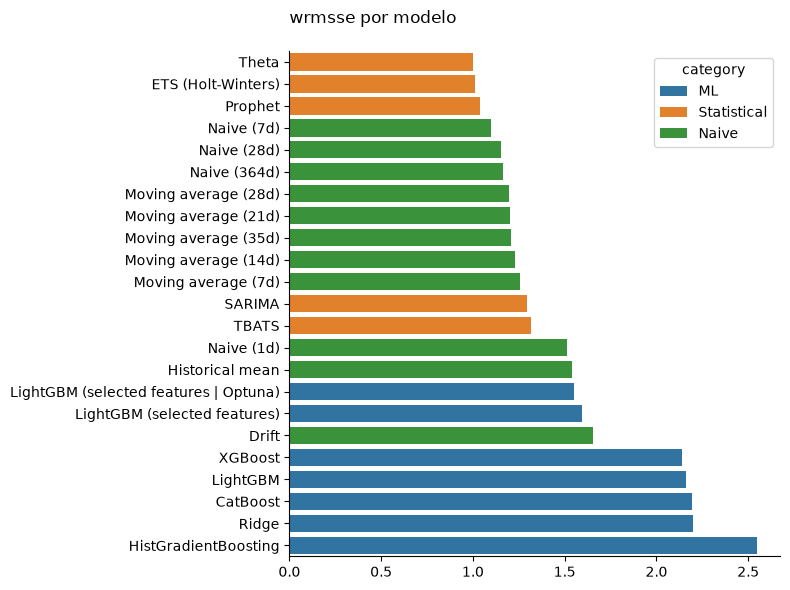

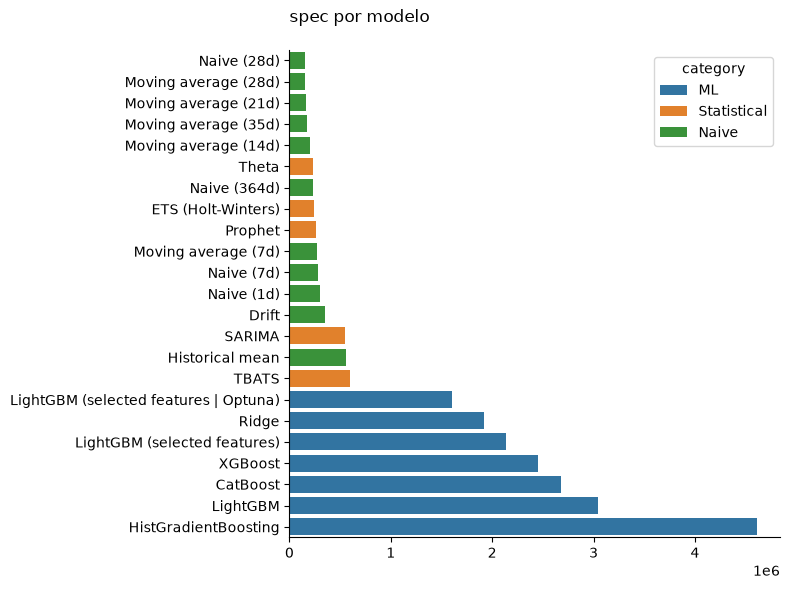

In [59]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [60]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(300_000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                            feature  mean_abs_shap
0                           dept_id      83.470716
32                             lag5      73.459531
54                            lag28      49.096953
61   rolling_mean_lag1_window_size7      45.983850
24             days_to_thanksgiving      38.547573
..                              ...            ...
18                        month_sin       0.464763
97  rolling_mean_lag6_window_size14       0.378736
14                 event_type_1_enc       0.345739
13                  days_to_closure       0.110135
26                      zero_streak       0.058282

[126 rows x 2 columns]


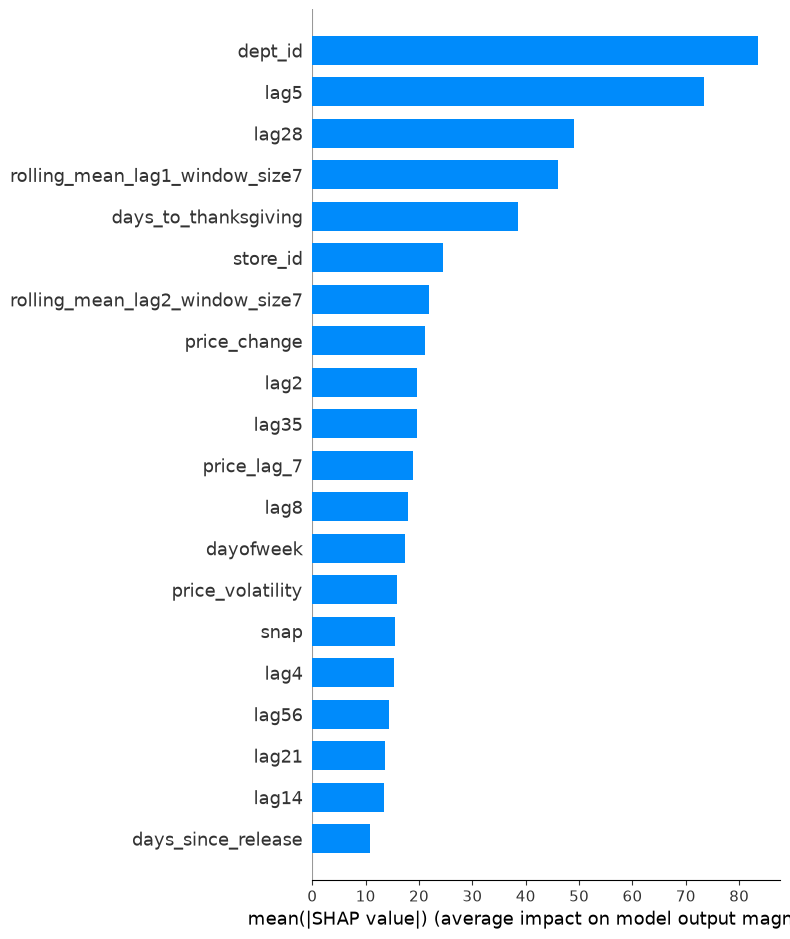

In [61]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


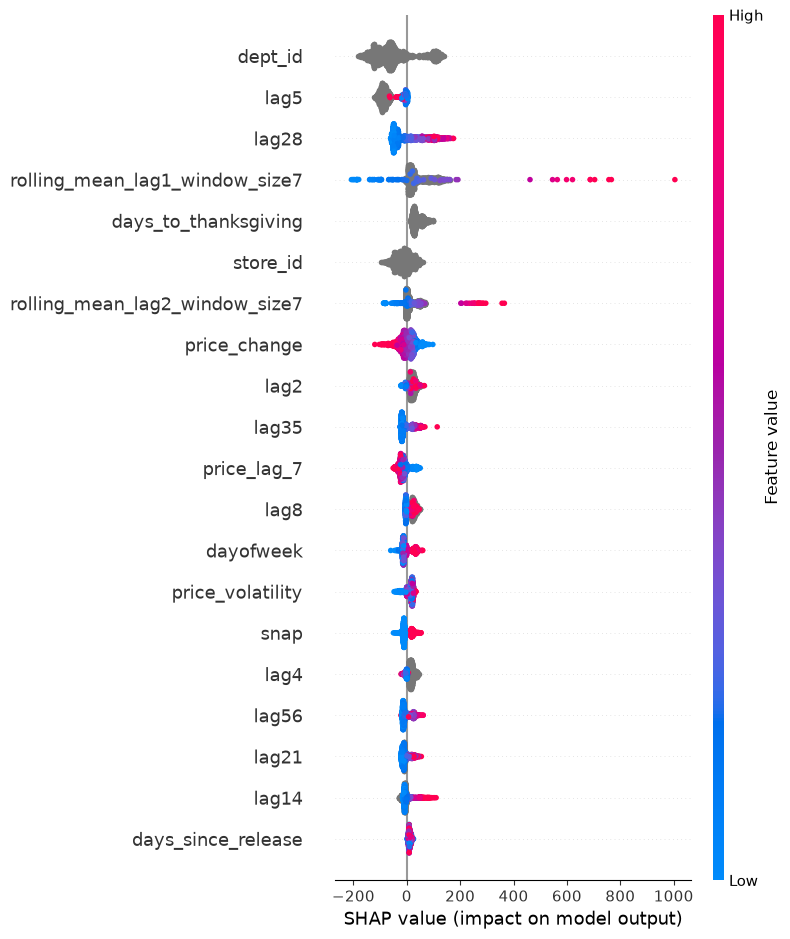

In [62]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [63]:
from src.evaluation import analizar_prediccion, plot_forecast, explain_prediction

In [64]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 32.41%
Test WRMSSE: 1.7745


In [65]:
from src.evaluation.metrics import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])

df_metrics.to_clipboard()

In [66]:
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_CA_3_CA,28,28,77367.0,36978.0,40389.0,40389.0,194847.031250,0.049948,0.522044,-0.522044,0.775805,28.000000,3.141588,3.865791,76282.446429
FOODS_3_FOODS_CA_1_CA,28,28,65999.0,37171.0,28828.0,28828.0,167972.828125,0.043059,0.436794,-0.436794,0.599414,28.000000,2.554480,2.815327,43528.366071
HOUSEHOLD_1_HOUSEHOLD_CA_3_CA,28,28,38478.0,30441.0,8037.0,8277.0,163889.625000,0.042012,0.215110,-0.208873,0.287765,27.188112,1.904280,1.920139,5856.705357
FOODS_3_FOODS_WI_2_WI,28,28,67991.0,34452.0,33539.0,34051.0,154892.234375,0.039706,0.500816,-0.493286,0.714080,27.578984,3.642509,4.277378,58446.330357
FOODS_3_FOODS_CA_2_CA,28,28,57132.0,33263.0,23869.0,23975.0,146760.937500,0.037622,0.419642,-0.417787,0.580375,27.876204,3.781883,4.051594,32402.937500


In [67]:
df_metrics.nsmallest(5,'wrmsse')

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
HOBBIES_1_HOBBIES_WI_1_WI,28,28,10906.0,11981.0,-1075.0,1893.0,41999.480469,0.010766,0.173574,0.098570,0.196846,-15.900687,0.697204,0.755038,189.312500
HOUSEHOLD_1_HOUSEHOLD_WI_1_WI,28,28,16555.0,16247.0,308.0,2040.0,60210.589844,0.015435,0.123226,-0.018605,0.152349,4.227451,0.750202,0.819440,101.098214
FOODS_1_FOODS_CA_1_CA,28,28,9587.0,9989.0,-402.0,1300.0,24644.589844,0.006318,0.135600,0.041932,0.158502,-8.658462,0.764505,0.837409,50.821429
FOODS_2_FOODS_TX_1_TX,28,28,9901.0,11194.0,-1293.0,1603.0,35904.660156,0.009204,0.161903,0.130593,0.201796,-22.585153,0.766508,0.872076,263.276786
HOBBIES_1_HOBBIES_CA_4_CA,28,28,10468.0,9799.0,669.0,1387.0,40467.789062,0.010374,0.132499,-0.063909,0.151500,13.505407,0.781186,0.861587,226.964286


In [71]:
df_metrics.nsmallest(5,'wrmsse')

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
HOBBIES_1_HOBBIES_WI_1_WI,28,28,10906.0,11981.0,-1075.0,1893.0,41999.480469,0.010766,0.173574,0.098570,0.196846,-15.900687,0.697204,0.755038,189.312500
HOUSEHOLD_1_HOUSEHOLD_WI_1_WI,28,28,16555.0,16247.0,308.0,2040.0,60210.589844,0.015435,0.123226,-0.018605,0.152349,4.227451,0.750202,0.819440,101.098214
FOODS_1_FOODS_CA_1_CA,28,28,9587.0,9989.0,-402.0,1300.0,24644.589844,0.006318,0.135600,0.041932,0.158502,-8.658462,0.764505,0.837409,50.821429
FOODS_2_FOODS_TX_1_TX,28,28,9901.0,11194.0,-1293.0,1603.0,35904.660156,0.009204,0.161903,0.130593,0.201796,-22.585153,0.766508,0.872076,263.276786
HOBBIES_1_HOBBIES_CA_4_CA,28,28,10468.0,9799.0,669.0,1387.0,40467.789062,0.010374,0.132499,-0.063909,0.151500,13.505407,0.781186,0.861587,226.964286


In [69]:
CASES = ['HOUSEHOLD_1_HOUSEHOLD_TX_3_TX', 'HOBBIES_1_HOBBIES_WI_1_WI','HOUSEHOLD_2_HOUSEHOLD_CA_2_CA']

df_metrics.to_clipboard(decimal=",", sep="\t")

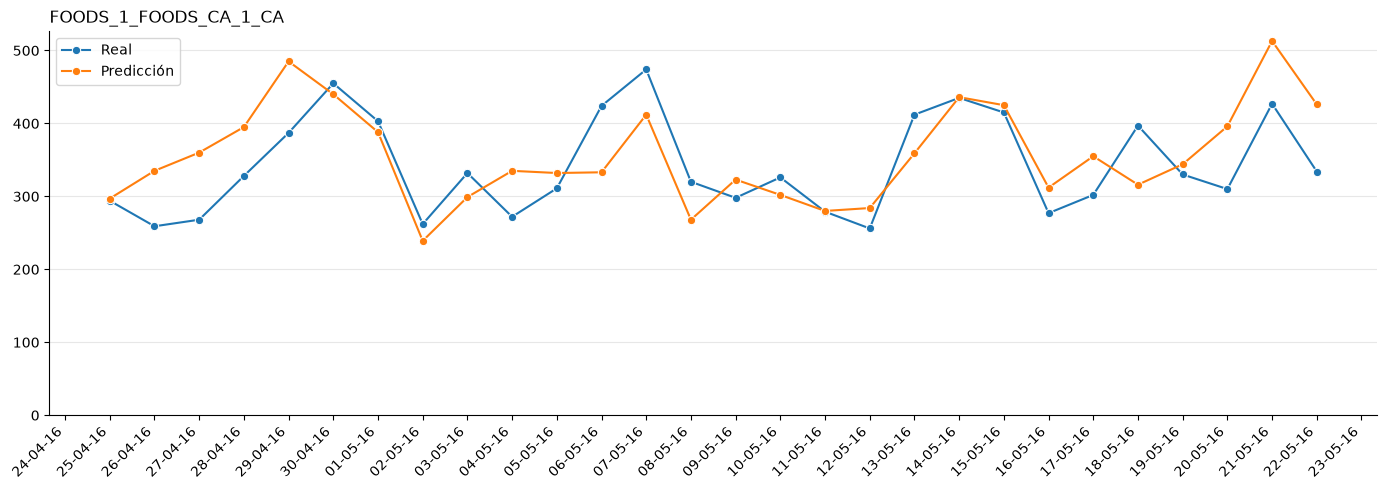

################################################## Date: 2016-05-14 00:00:00 ##################################################


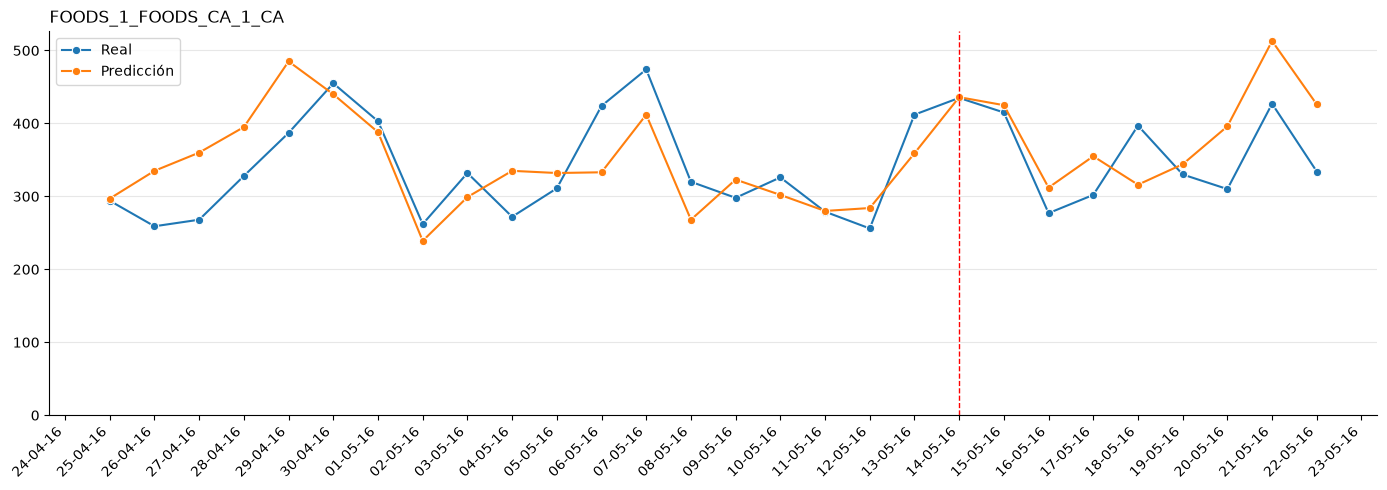

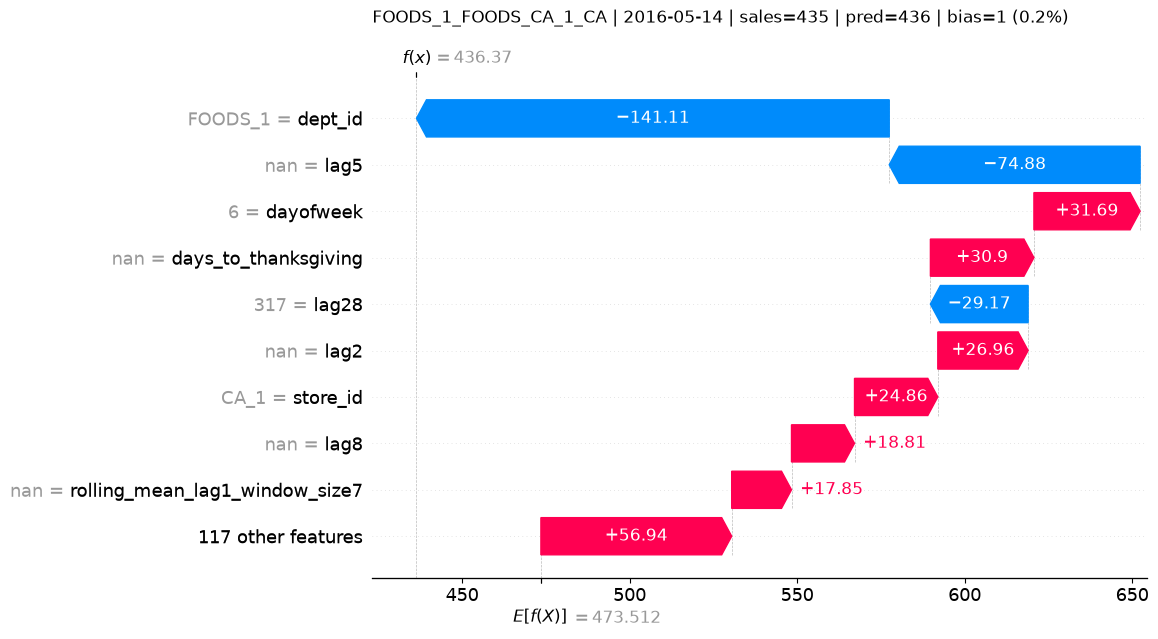

################################################## Date: 2016-05-11 00:00:00 ##################################################


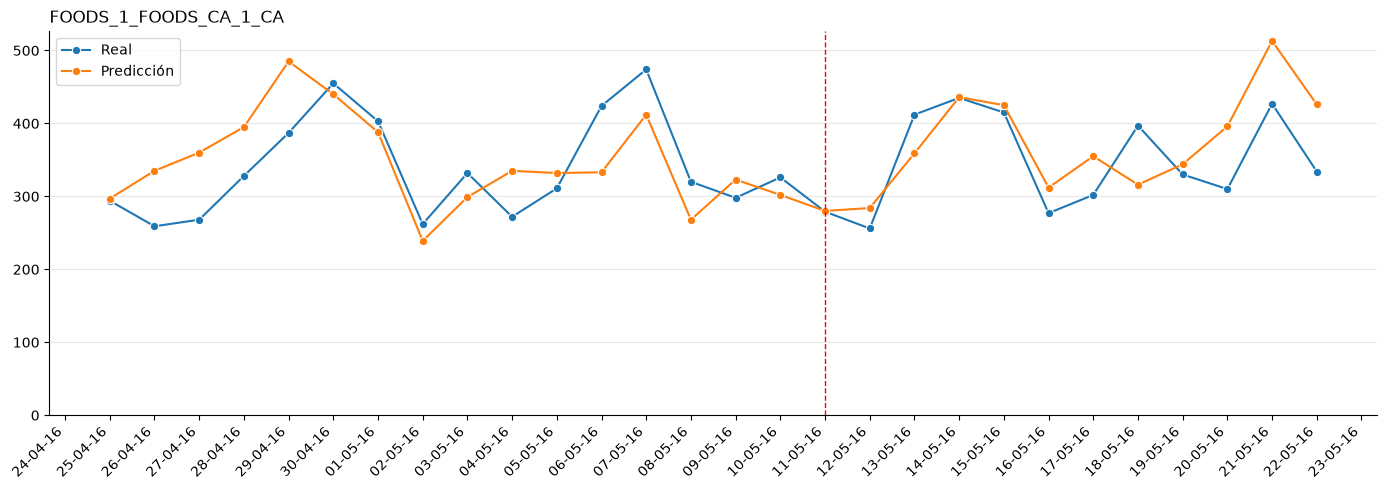

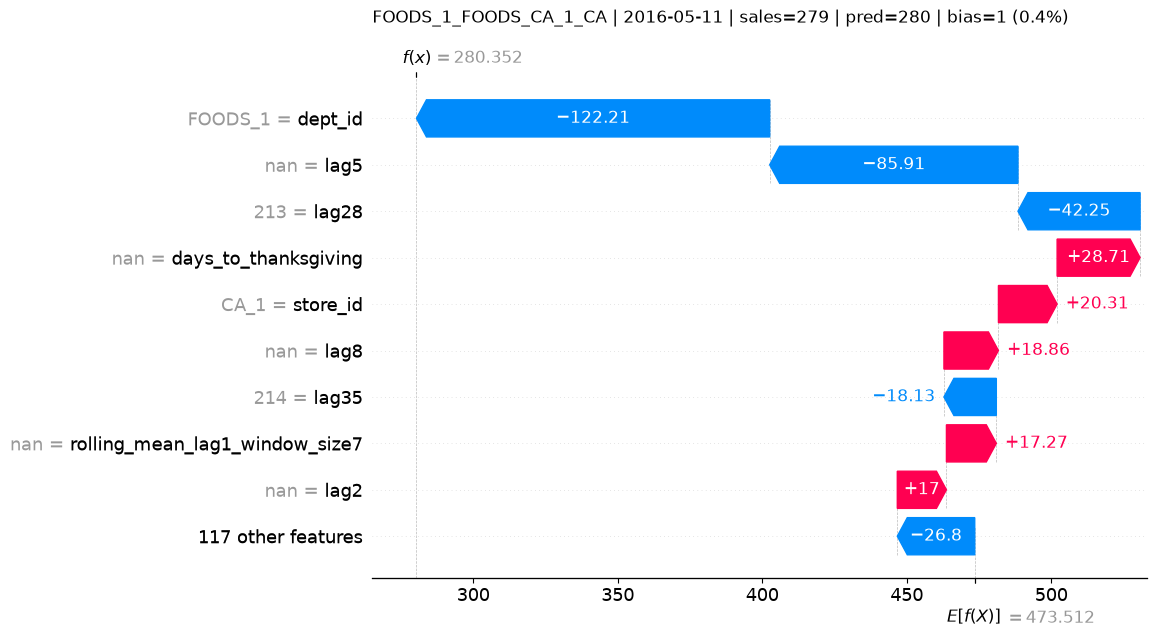

################################################## Date: 2016-04-25 00:00:00 ##################################################


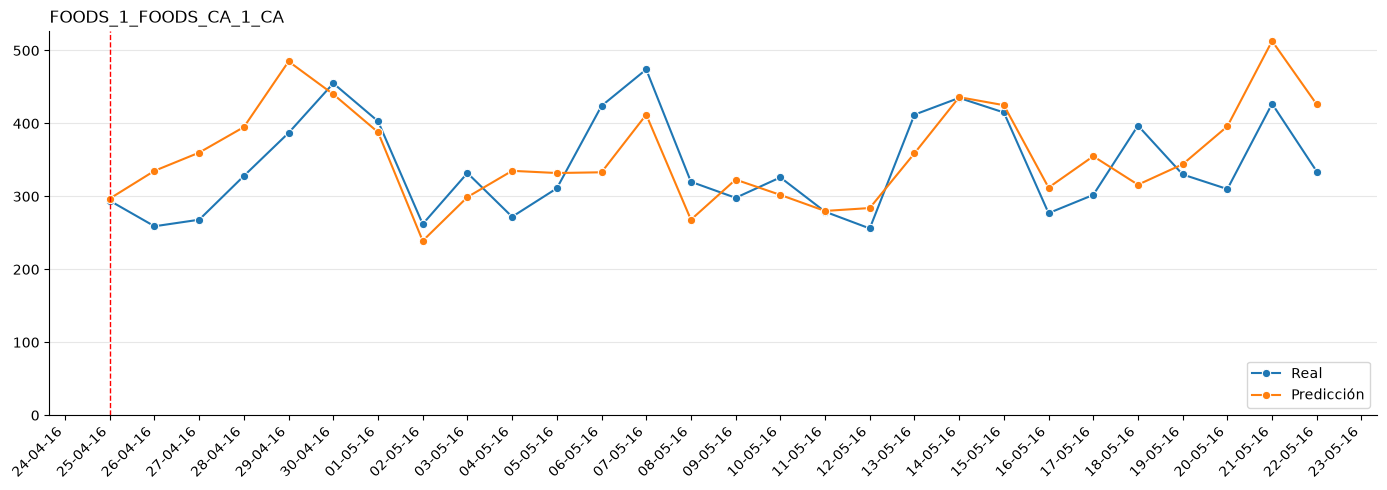

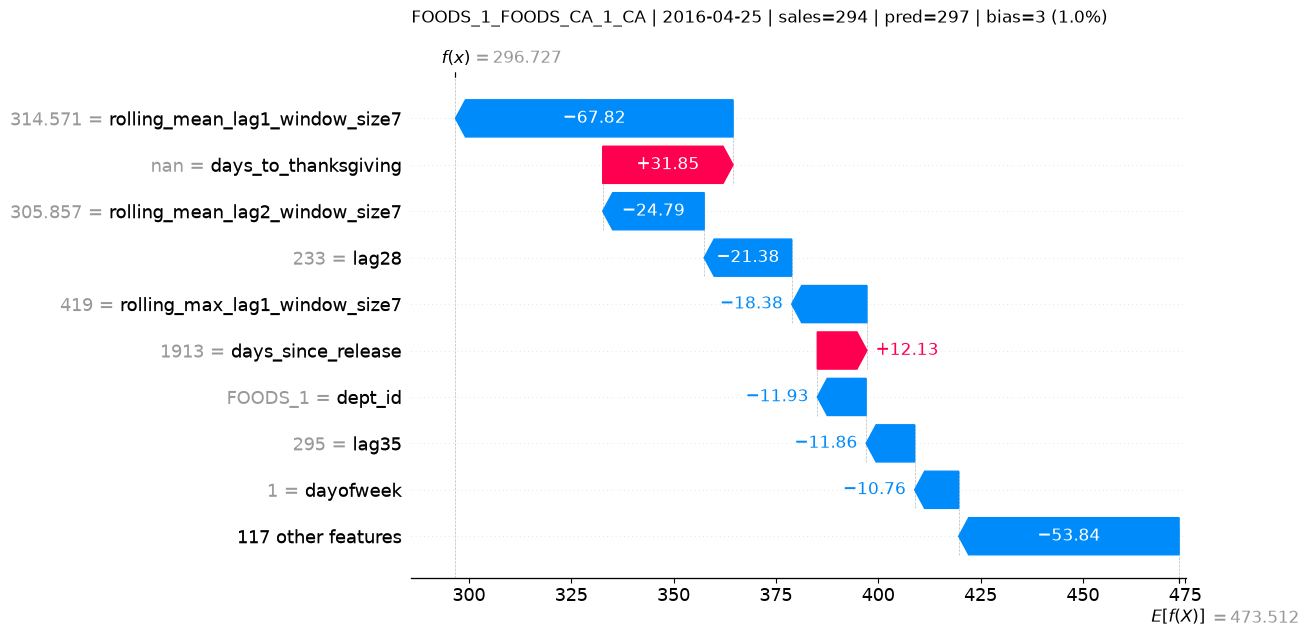

################################################## Date: 2016-04-27 00:00:00 ##################################################


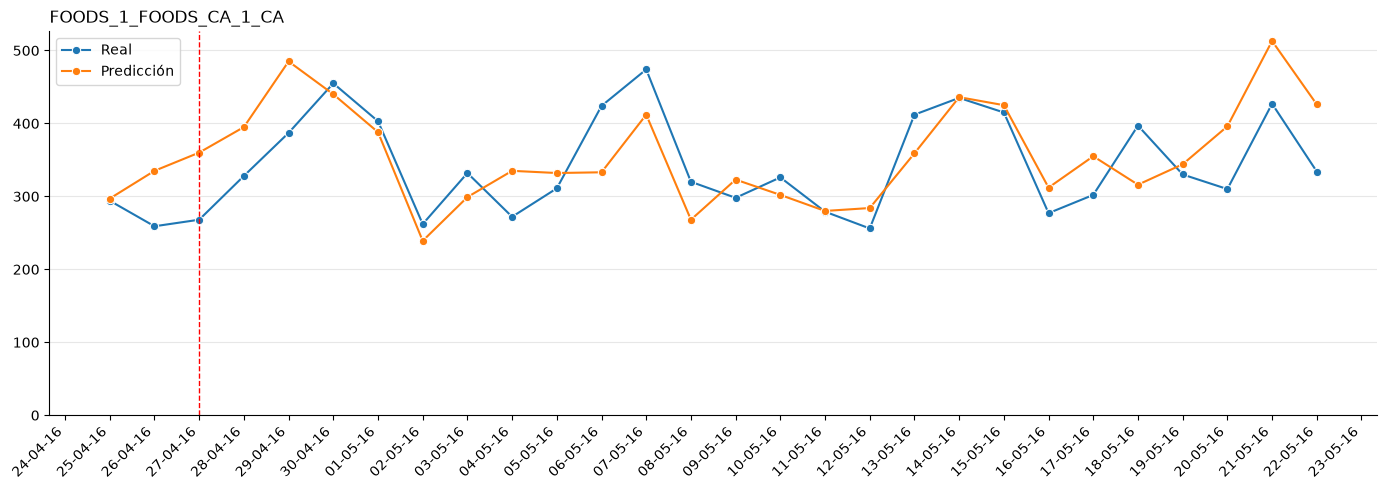

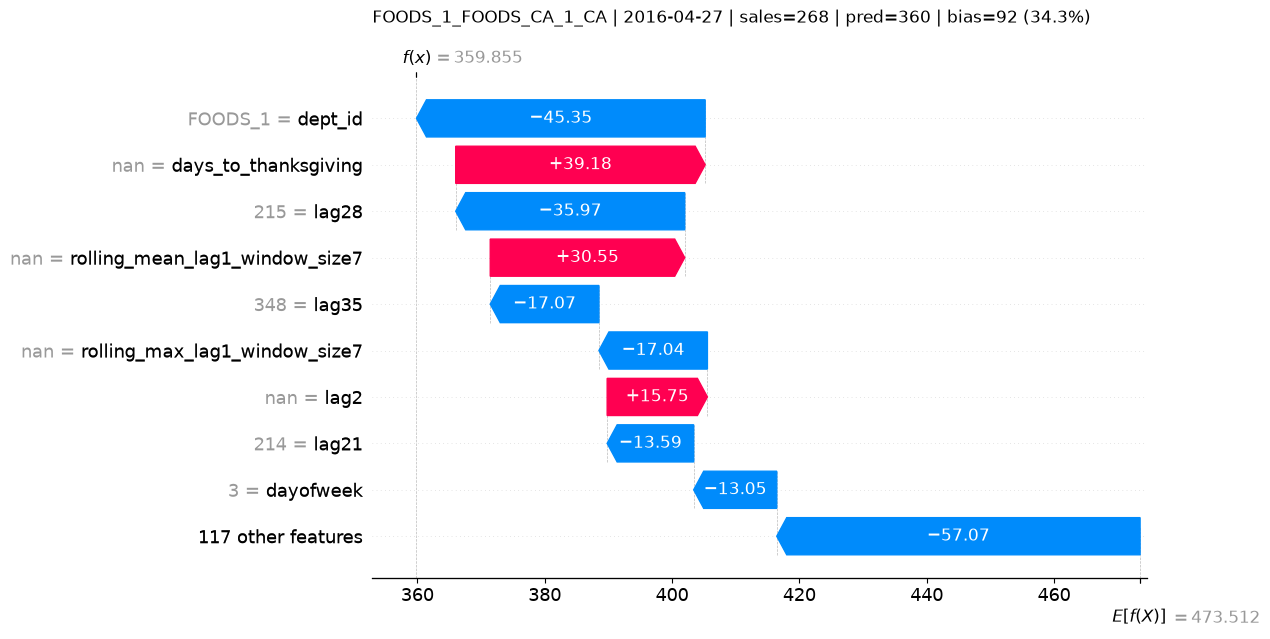

################################################## Date: 2016-04-26 00:00:00 ##################################################


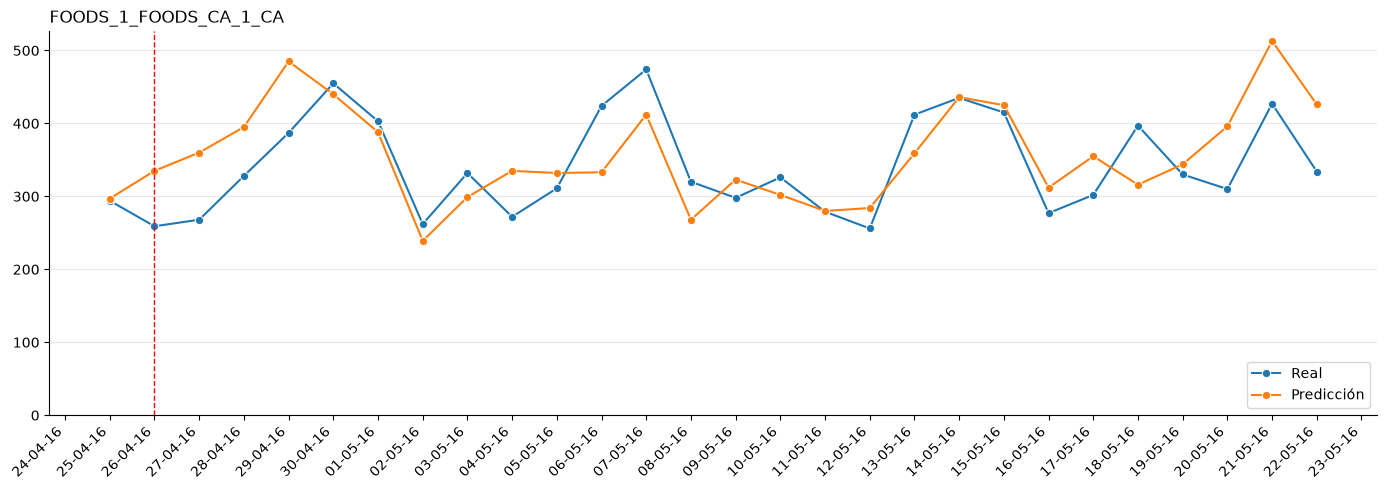

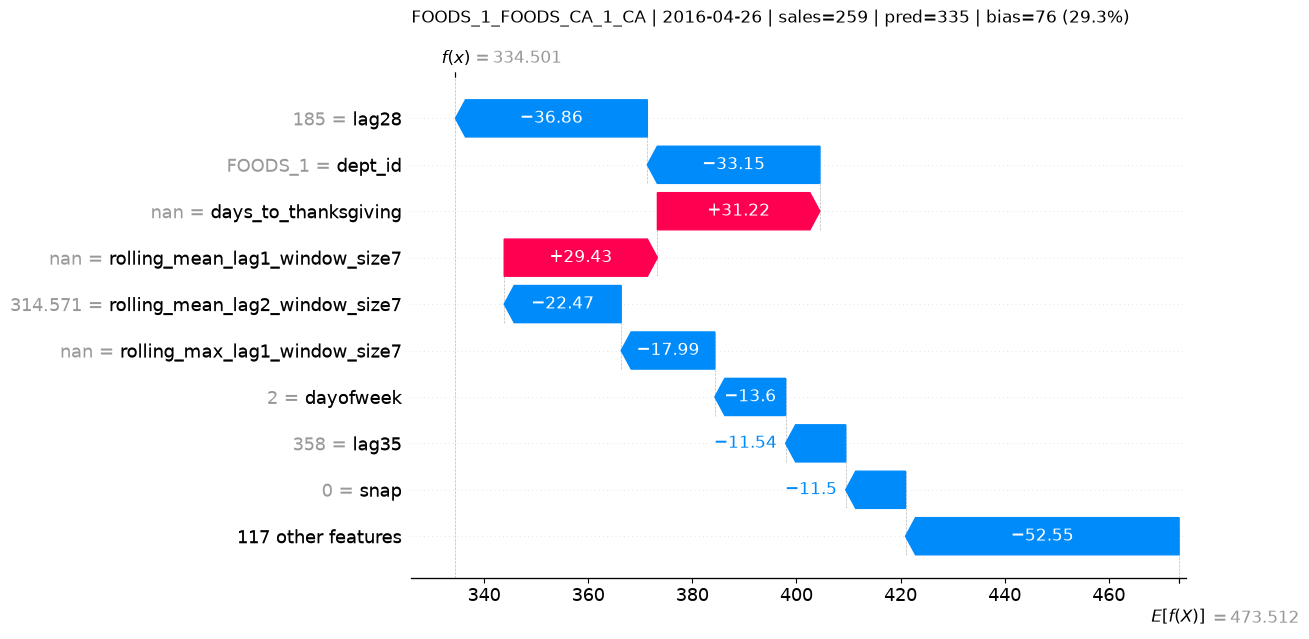

################################################## Date: 2016-05-20 00:00:00 ##################################################


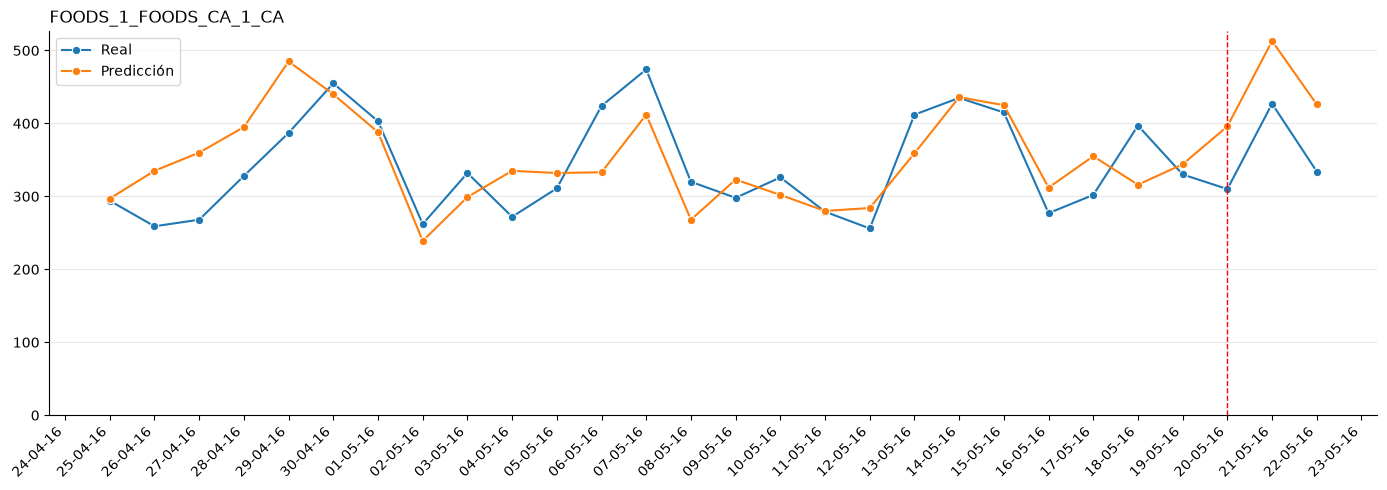

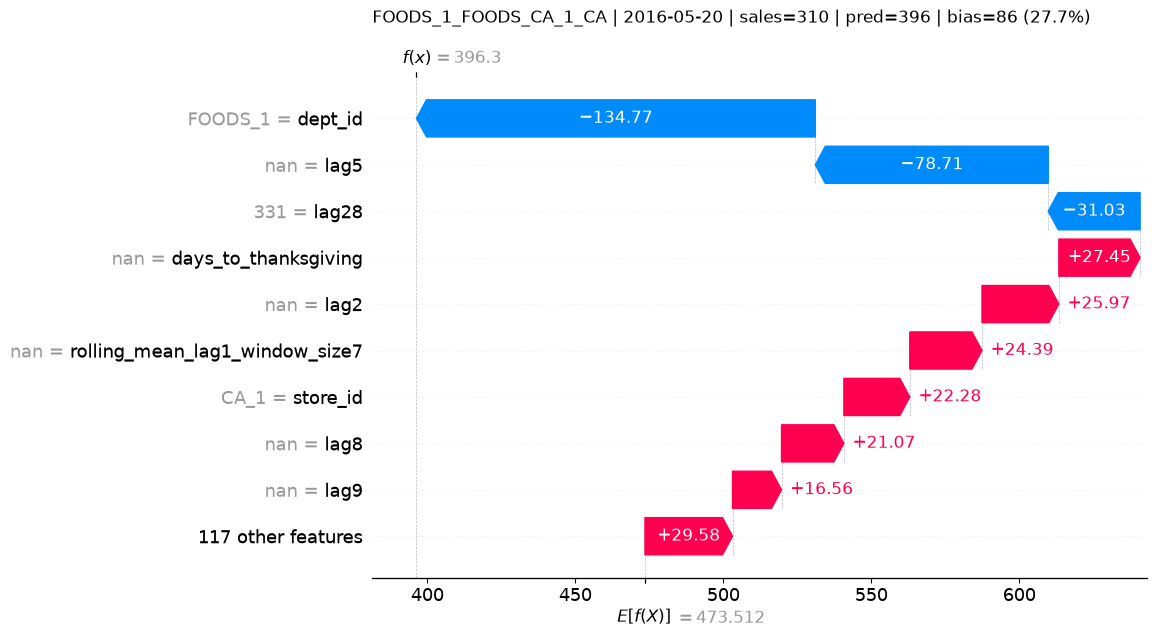

In [78]:
AGG_ID = 'FOODS_1_FOODS_CA_1_CA'

top_best_dates = df_pred.query(f'agg_id == "{AGG_ID}"').nsmallest(3, 'wape')['date']
top_error_dates = df_pred.query(f'agg_id == "{AGG_ID}"').nlargest(3, 'wape')['date']

plot_forecast(df_pred, 'sales', agg_id=AGG_ID)

for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], agg_id=AGG_ID, explainer=explainer, date=i)

for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], agg_id=AGG_ID, explainer=explainer, date=i)